In [1]:
import model
import importlib
importlib.reload(model)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mesa.visualization import SolaraViz, SpaceRenderer, make_plot_component
from mesa import batch_run
import numpy as np
import sys

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.options.display.float_format = "{:.3f}".format

init_variables = {
    # Variables

    "V": 0,
    "M_A": 0,
    # TODO: M_A at t=1 is actually not defined. but setting 0 is justified?

    # Some variables will be calculated in the model
    # or received from the environment
    "r": None,
    "rpe": None,

    # Parameters

    # Parameter for the exponential moving average of anger
    "lambda_A": np.linspace(0, 1, 20),

    # Controllability
    "C": np.linspace(0, 1, 20),

    # Learning rate
    "eta": np.linspace(0, 1, 20),

    # Discounting factor
    "gamma": np.linspace(0, 1, 20),
}

# rng = np.random.default_rng(12345)

# Number of runs per scenario
# seed_values = rng.integers(0, sys.maxsize, size=(5,))

results = batch_run(
    model.IrritabilityModel,
    parameters=init_variables,
    data_collection_period=1,  # collect data for every step
    number_processes=16,
    max_steps=130,
)

# starter_model = model.IrritabilityModel(init_variables=init_variables,
#                                         init_parameters=init_parameters,
#                                         seed=12345)
# Run a simulation for a single agent
# n_ticks = 100
# for _ in range(n_ticks):
#     starter_model.step()
#
# # Extract data and plot
# data = starter_model.datacollector.get_agent_vars_dataframe()
#
# g = sns.lineplot(data=data,
#                  y="p_A",
#                  x="Step",
#                  label="Probability aggressive")
#
# g = sns.lineplot(data=data,
#                  y=data["M_A"].abs(),
#                  x="Step",
#                  color="Orange",
#                  label="Anger/frustration (absolute)")
#
# g.set(title="Anger and aggressive action",
#       ylabel="Value");
#
# plt.xlim(0, 40)
# plt.ylim(0, 1)
# plt.show()
# display(data)

  0%|          | 0/160000 [00:00<?, ?it/s]

/home/soelderer/projects/formal_model_irritability/simulations/.venv/lib/python3.13/site-packages/mesa/discrete_space/grid.py:103: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  super().__init__(capacity=capacity, random=random, cell_klass=cell_klass)
/home/soelderer/projects/formal_model_irritability/simulations/.venv/lib/python3.13/site-packages/mesa/discrete_space/grid.py:103: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  super().__init__(capacity=capacity, random=random, cell_klass=cell_klass)
/home/soelderer/projects/formal_model_irritability/simulations/.venv/lib/python3.13/site-packages/mesa/discrete_space/grid.py:103: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  super().__init__(capacity=capacit

# A glimpse at the data

In [13]:
results_df = pd.DataFrame(results)

print(results_df["C"].unique())

# results1 = results_df[results_df["RunId"] == 230]

# gamma = 0.57894737
# eta = 0.05263158
# lambda_A = 0.15789474
# C = 1

results1 = results_df[
    np.isclose(results_df["gamma"], 0.57894737) &
    np.isclose(results_df["eta"], 0.05263158) &
    np.isclose(results_df["lambda_A"], 0.84210526) &
    np.isclose(results_df["C"], 1)
]

# print(results_df.loc[22826, "eta"], repr(results_df.loc[22826, "eta"]))
# print(results_df.loc[22826, "lambda_A"], repr(results_df.loc[22826, "lambda_A"]))
# print(results_df.loc[22826, "C"], repr(results_df.loc[22826, "C"]))

# print(results_df["gamma"].dtype)


# results1.head(n=200)

# Prior to the first step, many things are not defined (e.g. action)
# results_df = results_df[results_df["Step"] > 0]

# results_df.head(n=200)

# results_df.columns

[0.         0.05263158 0.10526316 0.15789474 0.21052632 0.26315789
 0.31578947 0.36842105 0.42105263 0.47368421 0.52631579 0.57894737
 0.63157895 0.68421053 0.73684211 0.78947368 0.84210526 0.89473684
 0.94736842 1.        ]


# Some plots

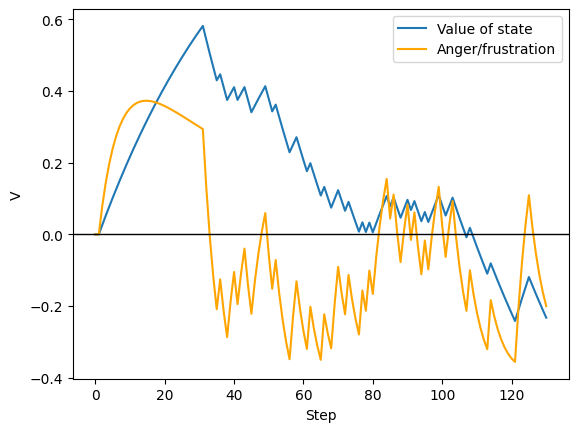

In [14]:
g = sns.lineplot(data=results1,
                 y="V",
                 x="Step",
                 label="Value of state")

g = sns.lineplot(data=results1,
                 y=results1["M_A"],
                 x="Step",
                 color="Orange",
                 label="Anger/frustration")

# g.set(title="Anger and aggressive action",
#       ylabel="Value");
plt.axhline(y=0, color='black', linewidth=1)  # horizontal line at y=0

# plt.xlim(0, 130)
# plt.ylim(0, 1)
plt.show()